# Retail Intelligence & Recommendation System using Instacart Data
## Notebook 1: Data Understanding & Exploratory Data Analysis (EDA)

This notebook focuses on loading, cleaning, and exploring the Instacart dataset. We will perform comprehensive analysis of products, orders, customers, and relationships to establish key business insights.

### Downsampling Strategy
To optimize performance and memory, we downsample the dataset to the first 5,000 customers (`user_id <= 5000`). This maintains statistical significance while allowing interactive visualizations and models to run efficiently.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


### 1. Data Loading & Cleaning
We load all six tables of the Instacart dataset and filter orders and order-products to only include users with ID <= 5000.

In [2]:
data_dir = Path("../../datasets/instacart_market_ basket")

# Load dimensions
aisles = pd.read_csv(data_dir / "aisles.csv")
departments = pd.read_csv(data_dir / "departments.csv")
products = pd.read_csv(data_dir / "products.csv")

# Load orders and filter to user_id <= 5000
orders_full = pd.read_csv(data_dir / "orders.csv")
orders = orders_full[orders_full['user_id'] <= 5000]
order_ids = set(orders['order_id'])

# Load order-product mappings and filter by order_ids
op_prior = pd.read_csv(data_dir / "order_products__prior.csv")
op_prior = op_prior[op_prior['order_id'].isin(order_ids)]

op_train = pd.read_csv(data_dir / "order_products__train.csv")
op_train = op_train[op_train['order_id'].isin(order_ids)]

print(f"Loaded {len(orders)} orders for 5,000 customers.")
print(f"Prior items: {len(op_prior)}, Train items: {len(op_train)}.")

Loaded 81832 orders for 5,000 customers.
Prior items: 761750, Train items: 33782.


#### Merge Tables
We combine products, aisles, and departments into a unified product catalog. Then, we concatenate the prior and train order-product mappings and merge them with the orders and product tables.

In [3]:
# Merge products catalog
product_details = products.merge(aisles, on='aisle_id').merge(departments, on='department_id')

# Combine order products
op_prior['eval_set'] = 'prior'
op_train['eval_set'] = 'train'
op_all = pd.concat([op_prior, op_train], ignore_index=True)

# Merge everything into a master dataframe
df = op_all.merge(orders, on='order_id').merge(product_details, on='product_id')
print(f"Master DataFrame Shape: {df.shape}")
df.head()

Master DataFrame Shape: (795532, 16)


,order_id,product_id,add_to_cart_order,reordered,eval_set_x,user_id,eval_set_y,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,8,23423,1,1,prior,3107,prior,5,4,6,17.0,Original Hawaiian Sweet Rolls,43,3,buns rolls,bakery
1,40,10070,1,1,prior,382,prior,29,1,15,23.0,Organic 1% Low Fat Milk,84,16,milk,dairy eggs
2,40,42450,2,1,prior,382,prior,29,1,15,23.0,Macaroni & Cheese,38,1,frozen meals,frozen
3,40,33198,3,1,prior,382,prior,29,1,15,23.0,Sparkling Natural Mineral Water,115,7,water seltzer sparkling water,beverages
4,40,34866,4,1,prior,382,prior,29,1,15,23.0,Chocolate Milk 1% Milkfat,84,16,milk,dairy eggs


#### Missing Values & Duplicates

In [4]:
print("Missing Values in Orders:")
print(orders.isnull().sum())

print("\nDuplicate Rows in Master df:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values in Orders:
order_id                     0
user_id                      0
eval_set                     0
order_number                 0
order_dow                    0
order_hour_of_day            0
days_since_prior_order    5000
dtype: int64

Duplicate Rows in Master df:
0

Data Types:
order_id                    int64
product_id                  int64
add_to_cart_order           int64
reordered                   int64
eval_set_x                    str
user_id                     int64
eval_set_y                    str
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
product_name                  str
aisle_id                    int64
department_id               int64
aisle                         str
department                    str
dtype: object


### 2. Product Analysis
We analyze purchasing frequency, top products, least purchased products, and sales across departments and aisles.

In [5]:
# Top 20 products
top_20 = df['product_name'].value_counts().head(20)
print("Top 20 Products:")
print(top_20)

# Least purchased products
least_purchased = df['product_name'].value_counts().tail(20)
print("\nLeast Purchased Products (Sample):")
print(least_purchased)

Top 20 Products:
product_name
Banana                    11023
Bag of Organic Bananas     9314
Organic Strawberries       6650
Organic Baby Spinach       5797
Organic Hass Avocado       5425
Organic Avocado            4102
Large Lemon                3991
Organic Raspberries        3701
Strawberries               3591
Limes                      3499
Organic Whole Milk         3455
Organic Garlic             2717
Cucumber Kirby             2618
Organic Yellow Onion       2562
Organic Blueberries        2529
Organic Zucchini           2401
Organic Fuji Apple         2188
Organic Lemon              2101
Organic Cucumber           2101
Organic Half & Half        2037
Name: count, dtype: int64

Least Purchased Products (Sample):
product_name
Frankincense, 100% Pure, Essential Oils                             1
Toasted Coconut Chips                                               1
Lexington Milk Chocolate Toffee Almond Crispy Cookies               1
Caffe Mocha Iced Coffee                      

#### Product Visualizations

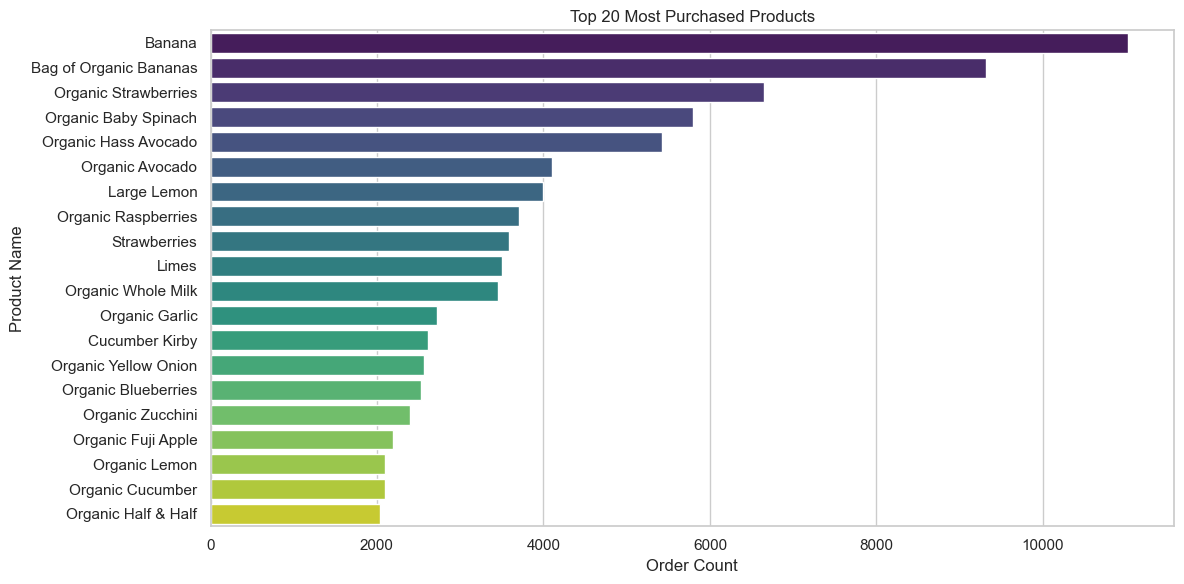

In [6]:
# Bar Chart: Top 20 products
plt.figure(figsize=(12, 6))
sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')
plt.title('Top 20 Most Purchased Products')
plt.xlabel('Order Count')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

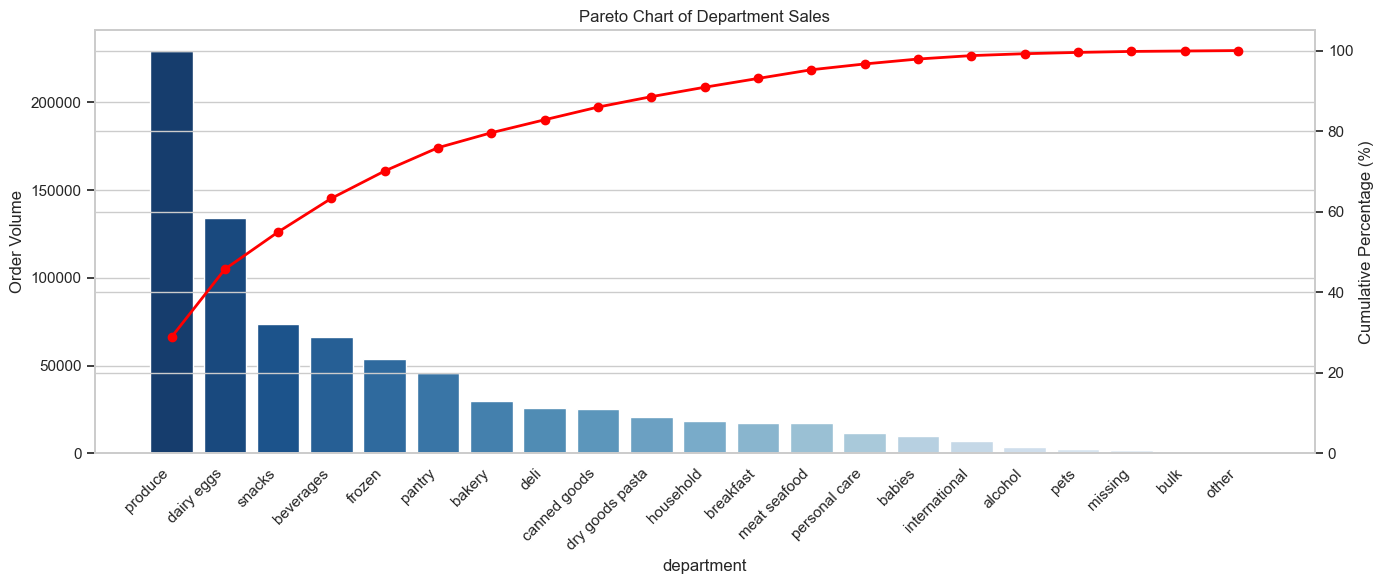

In [7]:
# Pareto Chart for Departments
dept_counts = df['department'].value_counts()
dept_pct = dept_counts.cumsum() / dept_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(x=dept_counts.index, y=dept_counts.values, ax=ax1, palette='Blues_r')
ax1.set_xticklabels(dept_counts.index, rotation=45, ha='right')
ax1.set_ylabel('Order Volume')

ax2 = ax1.twinx()
ax2.plot(dept_pct.index, dept_pct.values, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 105)

plt.title('Pareto Chart of Department Sales')
plt.tight_layout()
plt.show()

In [8]:
# Treemap of Sales by Department and Aisle
treemap_df = df.groupby(['department', 'aisle']).size().reset_index(name='sales_volume')
fig = px.treemap(
    treemap_df, 
    path=['department', 'aisle'], 
    values='sales_volume', 
    title='Treemap of Department and Aisle Sales Distribution',
    color='sales_volume',
    color_continuous_scale='Viridis'
)
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

In [9]:
# Sunburst Chart for top departments and their aisles
# Filter to top 8 departments to avoid cluttered chart
top_depts = df['department'].value_counts().head(8).index
sunburst_df = treemap_df[treemap_df['department'].isin(top_depts)]

fig = px.sunburst(
    sunburst_df, 
    path=['department', 'aisle'], 
    values='sales_volume', 
    title='Sunburst Chart of Top Departments and Aisles'
)
fig.show()

### 3. Order Analysis
We analyze order distributions across hours, weekdays, days since prior order, and basket sizes.

In [10]:
print("Orders per Customer (Summary):")
print(orders.groupby('user_id')['order_id'].nunique().describe())

# Basket Size
basket_sizes = df.groupby('order_id')['product_id'].count()
print("\nBasket Size Distribution (Summary):")
print(basket_sizes.describe())

Orders per Customer (Summary):
count    5000.000000
mean       16.366400
std        16.571116
min         4.000000
25%         6.000000
50%        10.000000
75%        20.000000
max       100.000000
Name: order_id, dtype: float64

Basket Size Distribution (Summary):
count    80032.000000
mean         9.940174
std          7.490466
min          1.000000
25%          5.000000
50%          8.000000
75%         13.000000
max         95.000000
Name: product_id, dtype: float64


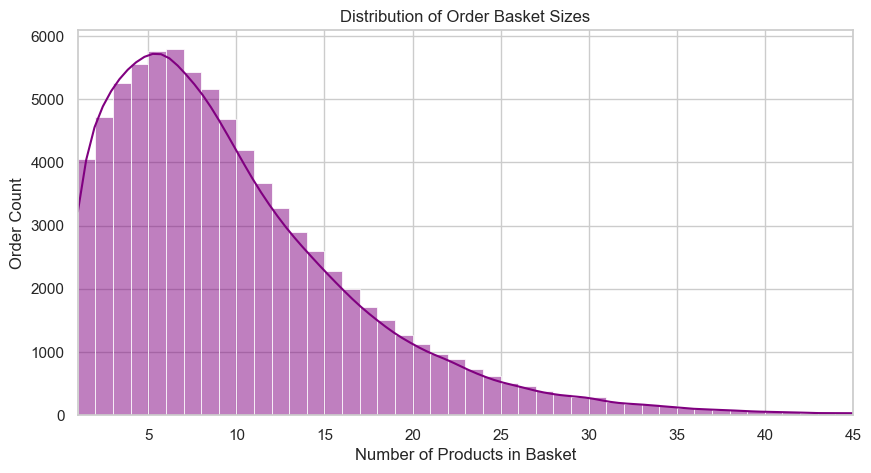

In [11]:
# Visualizations: Basket Size Histogram
plt.figure(figsize=(10, 5))
sns.histplot(basket_sizes, bins=range(1, 50), kde=True, color='purple')
plt.title('Distribution of Order Basket Sizes')
plt.xlabel('Number of Products in Basket')
plt.ylabel('Order Count')
plt.xlim(1, 45)
plt.show()

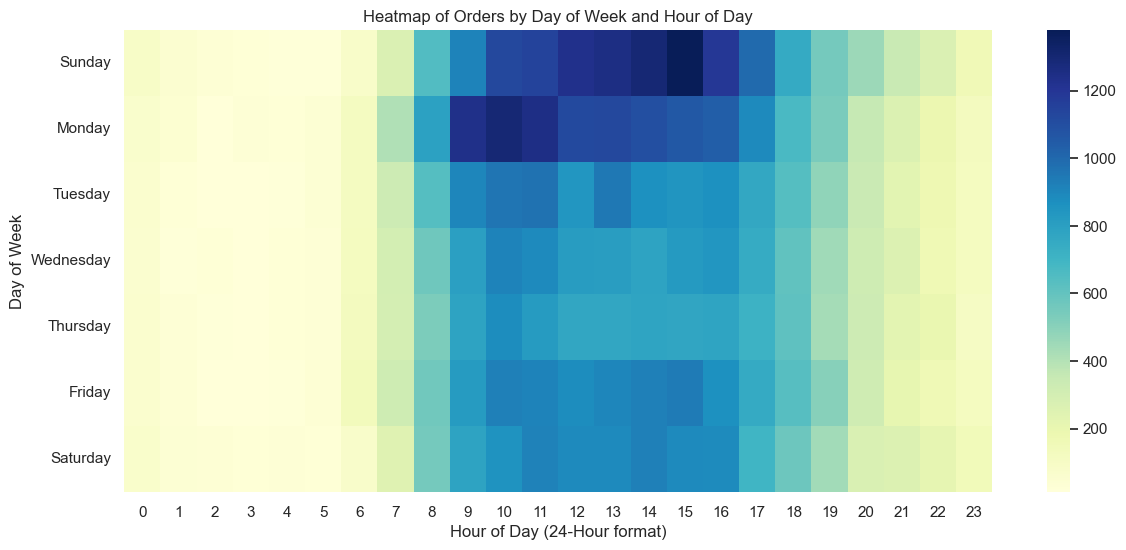

In [12]:
# Heatmap: Orders by hour of day and day of week
heat_df = orders.groupby(['order_dow', 'order_hour_of_day']).size().unstack(fill_value=0)
weekday_labels = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

plt.figure(figsize=(14, 6))
sns.heatmap(heat_df, yticklabels=weekday_labels, cmap='YlGnBu', annot=False, fmt='d')
plt.title('Heatmap of Orders by Day of Week and Hour of Day')
plt.xlabel('Hour of Day (24-Hour format)')
plt.ylabel('Day of Week')
plt.show()

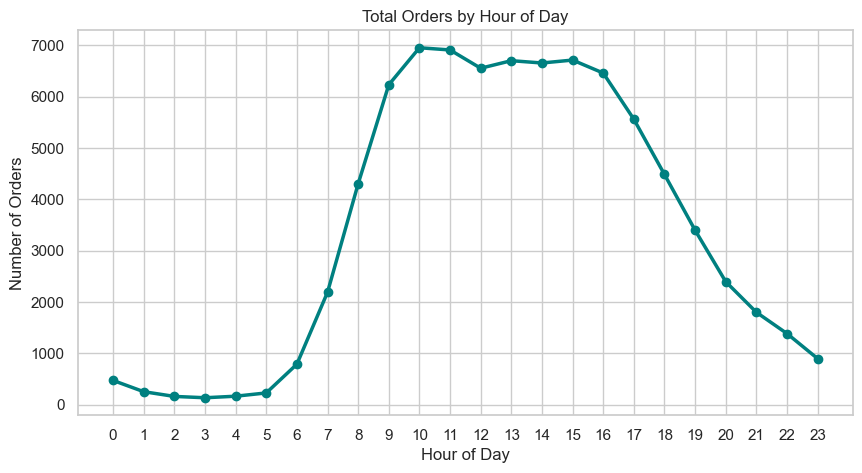

In [13]:
# Line Chart: Order volume by Hour of Day
hour_counts = orders['order_hour_of_day'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(hour_counts.index, hour_counts.values, marker='o', color='teal', linewidth=2.5)
plt.title('Total Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(range(24))
plt.show()

### 4. Customer Analysis
We calculate metrics such as average basket size, repeat purchase rate, and average products per order.

In [14]:
avg_basket_size = basket_sizes.mean()
repeat_purchase_rate = df['reordered'].mean() * 100
avg_orders_per_customer = orders.groupby('user_id')['order_id'].nunique().mean()

print(f"Average Basket Size: {avg_basket_size:.2f} items")
print(f"Repeat Purchase Rate (Reorder Rate): {repeat_purchase_rate:.2f}%")
print(f"Average Orders per Customer: {avg_orders_per_customer:.2f}")

Average Basket Size: 9.94 items
Repeat Purchase Rate (Reorder Rate): 58.91%
Average Orders per Customer: 16.37


### 5. Product Relationships
Which products are purchased together? Which departments are co-purchased?

In [15]:
# Find most common product pairs co-occurring in the same order
from collections import Counter
from itertools import combinations

# Group items by order
order_item_list = df.groupby('order_id')['product_name'].apply(list)

# Calculate pair frequencies
pairs = Counter()
for items in order_item_list:
    if len(items) > 1:
        # Sort names to treat (A, B) same as (B, A)
        pairs.update(combinations(sorted(list(set(items))), 2))

print("Top 15 Most Common Product Pairs Co-occurring:")
for pair, count in pairs.most_common(15):
    print(f"{pair[0]}  <--->  {pair[1]} : {count} orders")

Top 15 Most Common Product Pairs Co-occurring:
Bag of Organic Bananas  <--->  Organic Strawberries : 1619 orders
Bag of Organic Bananas  <--->  Organic Hass Avocado : 1586 orders
Banana  <--->  Organic Avocado : 1242 orders
Banana  <--->  Organic Strawberries : 1230 orders
Bag of Organic Bananas  <--->  Organic Baby Spinach : 1208 orders
Banana  <--->  Organic Baby Spinach : 1159 orders
Bag of Organic Bananas  <--->  Organic Raspberries : 1109 orders
Organic Hass Avocado  <--->  Organic Strawberries : 1092 orders
Banana  <--->  Large Lemon : 1046 orders
Banana  <--->  Strawberries : 1010 orders
Organic Baby Spinach  <--->  Organic Strawberries : 987 orders
Organic Raspberries  <--->  Organic Strawberries : 970 orders
Organic Baby Spinach  <--->  Organic Hass Avocado : 870 orders
Banana  <--->  Cucumber Kirby : 798 orders
Bag of Organic Bananas  <--->  Organic Whole Milk : 758 orders


In [16]:
# Department Co-occurrence
order_dept_list = df.groupby('order_id')['department'].apply(lambda x: sorted(list(set(x))))
dept_pairs = Counter()
for depts in order_dept_list:
    if len(depts) > 1:
        dept_pairs.update(combinations(depts, 2))

print("Top 10 Most Common Department Pairs Co-occurring:")
for pair, count in dept_pairs.most_common(10):
    print(f"{pair[0]}  <--->  {pair[1]} : {count} orders")

Top 10 Most Common Department Pairs Co-occurring:
dairy eggs  <--->  produce : 43609 orders
produce  <--->  snacks : 27190 orders
beverages  <--->  produce : 26239 orders
dairy eggs  <--->  snacks : 25869 orders
beverages  <--->  dairy eggs : 25445 orders
frozen  <--->  produce : 23277 orders
pantry  <--->  produce : 22596 orders
dairy eggs  <--->  frozen : 21942 orders
dairy eggs  <--->  pantry : 21100 orders
beverages  <--->  snacks : 18516 orders
